The goal here is to generate phylogenetic trees for the top 4 families which are represented in each individual's seroreactivity profile. 

So I want to build a tree for the Arenaviridae, Nairoviridae, Phenuiviridae and Hantaviridae family. 

The origin (represented as a node) should represent the viral family, with branches going out for each genus (represented as a node), ending in leaves (also represented as a circular node) for each species that is represented in the library. 
The size of each node should correspond to the fraction of seroreactivity observed in the cohort for this family / genus / species. 

My input is a peptide dataframe (/data1/sporak/Lassa_fever/Lassa_Fever_growup2/PhIP-Seq/Lassa_Lib/All_source_plates_Analysis/lasv_phipseq_2026/peptides_passing_filtering_082626.csv) which includes the filtered peptides (so hits for this cohort), and this peptide dataframe has two columns which represent the fraction seropositive in this cohort for this peptide, but also columns named family, genus, species which correspond to the taxonomy this peptide belongs to. 

Now I am also giving this script the entire peptide library as a peptide metadata (PhIP-Seq/Lassa_Lib/All_source_plates_Analysis/lassa_library_sequences_species_standardized_070726.csv). 

here we also have columns representing the family, genus, species.

In [1]:
import math
from pathlib import Path

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

%matplotlib inline

In [1]:
import pandas as pd

hits_df = pd.read_csv('peptides_passing_filtering_082626.csv')

library_df = pd.read_csv('../lassa_library_sequences_species_standardized_070726.csv')

ictv_df = pd.read_csv('ICTV_Master_Species_List_2025_MSL41.v1.csv')

In [3]:
FAMILY_COL = "family"
GENUS_COL = "genus"
SPECIES_COL = "species"

# Fraction of the cohort seropositive to this peptide.
FRACTION_COL = "frac_pass_z_in_SL"

FAMILIES = ["Arenaviridae", "Nairoviridae", "Phenuiviridae", "Hantaviridae"]

# How per-peptide fractions roll up into species -> genus -> family node size:
#   "max"  -> a taxon "lights up" if ANY peptide/species under it is reactive
#   "mean" -> average reactivity across peptides/species under it
NODE_AGG = "max"

OUTDIR = Path("taxonomy_trees_out")
OUTDIR.mkdir(exist_ok=True)

In [4]:
print(hits_df.shape, library_df.shape)

(1323, 504) (90132, 19)


In [5]:
import os
print("cwd:", os.getcwd())
print("OUTDIR resolved:", OUTDIR.resolve())
print("exists:", OUTDIR.exists())
print("contents:", list(OUTDIR.glob("*")) if OUTDIR.exists() else "n/a")

cwd: /data1/sporak/Lassa_fever/Lassa_Fever_growup2/PhIP-Seq/Lassa_Lib/All_source_plates_Analysis/lasv_phipseq_2026
OUTDIR resolved: /data1/sporak/Lassa_fever/Lassa_Fever_growup2/PhIP-Seq/Lassa_Lib/All_source_plates_Analysis/lasv_phipseq_2026/taxonomy_trees_out
exists: True
contents: []


In [ ]:
def build_family_tree(family, hits_df, lib_df):
    #subset both dataframes to rows, the peptide hits after filtering and the peptide phage library
    # to the families of interest
    lib_f = lib_df[lib_df[FAMILY_COL] == family]
    hits_f = hits_df[hits_df[FAMILY_COL] == family].copy()
    if lib_f.empty:
        print(f"[{family}] not found in library file -- skipping")
        return None

    #renaming frac_pass_z_in_SL to _frac
    hits_f["_frac"] = hits_f[FRACTION_COL].astype(float)

    #the species table defines the tree's shape so which genera/species exist, regardless
    # of if they had any hits. you get a (genus, species) pair from the library file
    # for that family. this generates a dataframe with cols genus and species
    species_table = lib_f[[GENUS_COL, SPECIES_COL]].dropna().drop_duplicates()

    # this groups the peptide hits files by species and aggregates on the fraction col
    # we defined NODE_AGG to be 'max' so takes the maximum _frac value for that species. 
    # so keeps the single largest fraction among that species's peptides and throws out
    # the other two numbers. can change NODE_AGG to 'mean' to get the average _frac instead
    species_frac = (
        hits_f.groupby(SPECIES_COL)["_frac"].agg(NODE_AGG)
        if not hits_f.empty else pd.Series(dtype=float)
    )

    # G is an empty directed graph object from the networkx library. This is essentially a placeholder
    # for the nodes and edges where the edges have a direction, so parent to child, or here family to genus to species. 
    # important to have a direction because we don't want the reverse. 
    G = nx.DiGraph()

    # G.add_node adds a single node to the graph. 
    # level and size are arbitrary key attributes attached to that node which are stored internally. 
    # netowrkx lets you attach any metadata you want to a node this way. 
    # size gets overwritten later once the genus values have been computed. first need to walk the 
    # children to know the family's aggregate size. 
    # level is what plot_tree later uses to decide the node's color and which text-labeling branch to use. 
    G.add_node(family, level="family", size=0.0)

    genus_children = {}
    for _, row in species_table.iterrows():
        genus, species = row[GENUS_COL], row[SPECIES_COL]
        if genus not in G:
            G.add_node(genus, level="genus", size=0.0)
            #G.add_edge draws the directed connection between the family and the genus. 
            G.add_edge(family, genus)
        val = float(species_frac.get(species, 0.0))
        G.add_node(species, level="species", size=val)
        G.add_edge(genus, species)
        # creates a dictionary for each genus, with the values being the max fraction
        # for the species belonging to this genus. The genus size is built from the species sizes.
        # as the maximum value will be taken. 
        genus_children.setdefault(genus, []).append(val)

    for genus, vals in genus_children.items():
        #the size here will depend on the frac seropositive
        G.nodes[genus]["size"] = max(vals) if NODE_AGG == "max" else sum(vals) / len(vals)

    fam_vals = [G.nodes[g]["size"] for g in genus_children]
    G.nodes[family]["size"] = (
        (max(fam_vals) if NODE_AGG == "max" else sum(fam_vals) / len(fam_vals))
        if fam_vals else 0.0
    )
    return G


def radial_layout(G, root):
    # G.out_degree() counts a node's outgoing edges, so the number of children
    # a node with zero children is a leaf. that would be every species node. This builts
    # a set of all leaf names. The order doesn't matter yet, just the membership. 
    leaves_set = {n for n in G.nodes if G.out_degree(n) == 0}
    # this walks the whole tree depth-first starting from family and yields every node a 
    # visitation order. This gives the species in DFS order. This matters, as species belonging
    # to the same genus end up next to each other in the list. DFS fully explores one branch before
    # moving to the next. 
    leaves = [n for n in nx.dfs_preorder_nodes(G, root) if n in leaves_set]
    # leaf angle spreads the leaves evenly around a full circle. the first leaf gets angle 0, 
    # the next 2pi/N, and so on. enumerate supplies the index i. max(len(leaves), 1) avoids
    # a divide by zero if the tree somehow has no leaves. 
    leaf_angle = {leaf: 2 * math.pi * i / max(len(leaves), 1) for i, leaf in enumerate(leaves)}

    depth = nx.shortest_path_length(G, root)

    angle = {}
    def compute(node):
        children = list(G.successors(node))
        if not children:
            angle[node] = leaf_angle[node]
        else:
            for c in children:
                compute(c)
            angle[node] = sum(angle[c] for c in children) / len(children)
    compute(root)

    return {n: (depth[n] * math.cos(angle[n]), depth[n] * math.sin(angle[n])) for n in G.nodes}


LEVEL_COLOR = {"family": "#7a1f2b", "genus": "#c96a30", "species": "#3d7a5c"}
MIN_SIZE, MAX_SIZE = 60, 1400


def plot_tree(G, family, outpath=None):
    # get every nodes (x, y)
    pos = radial_layout(G, family)
    fig, ax = plt.subplots(figsize=(11, 11))

    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        ax.plot([x0, x1], [y0, y1], color="#999999", linewidth=1, zorder=1)

    for level in ("family", "genus", "species"):
        nodes = [n for n in G.nodes if G.nodes[n]["level"] == level]
        xs = [pos[n][0] for n in nodes]
        ys = [pos[n][1] for n in nodes]
        sizes = [MIN_SIZE + (MAX_SIZE - MIN_SIZE) * G.nodes[n]["size"] for n in nodes]
        ax.scatter(xs, ys, s=sizes, color=LEVEL_COLOR[level], edgecolor="black",
                   linewidth=0.6, zorder=3, label=level.capitalize())

    for n in G.nodes:
        x, y = pos[n]
        if G.nodes[n]["level"] == "species":
            ax.text(x * 1.05, y * 1.05, n, fontsize=7,
                    rotation=math.degrees(math.atan2(y, x)),
                    ha="left" if x >= 0 else "right", va="center")
        elif G.nodes[n]["level"] == "genus":
            ax.text(x, y, n, fontsize=8, fontweight="bold", ha="center", va="bottom")

    ax.text(0, 0, family, fontsize=12, fontweight="bold", ha="center", va="center")
    ax.set_title(f"{family} — node size = cohort seroreactivity fraction ({NODE_AGG})")
    ax.legend(loc="upper right", frameon=False)
    ax.set_aspect("equal")
    ax.axis("off")
    fig.tight_layout()
    if outpath is not None:
        fig.savefig(outpath, dpi=200)
    plt.show()


def to_newick(G, root):
    def rec(n):
        children = list(G.successors(n))
        label = n.replace(" ", "_").replace("(", "").replace(")", "").replace(",", "")
        if not children:
            return label
        return "(" + ",".join(rec(c) for c in children) + ")" + label
    return rec(root) + ";"

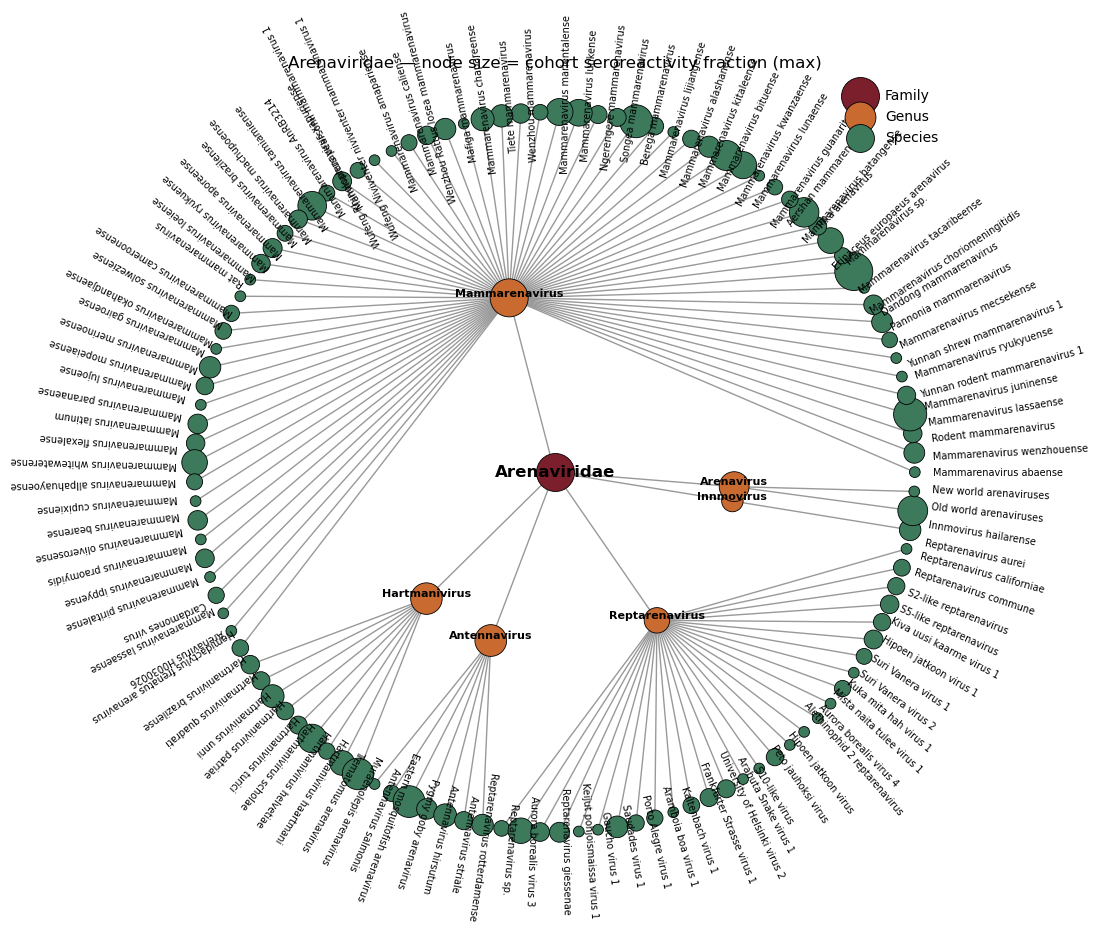

[Arenaviridae] 124 nodes -> taxonomy_trees_out/Arenaviridae.png, taxonomy_trees_out/Arenaviridae.nwk


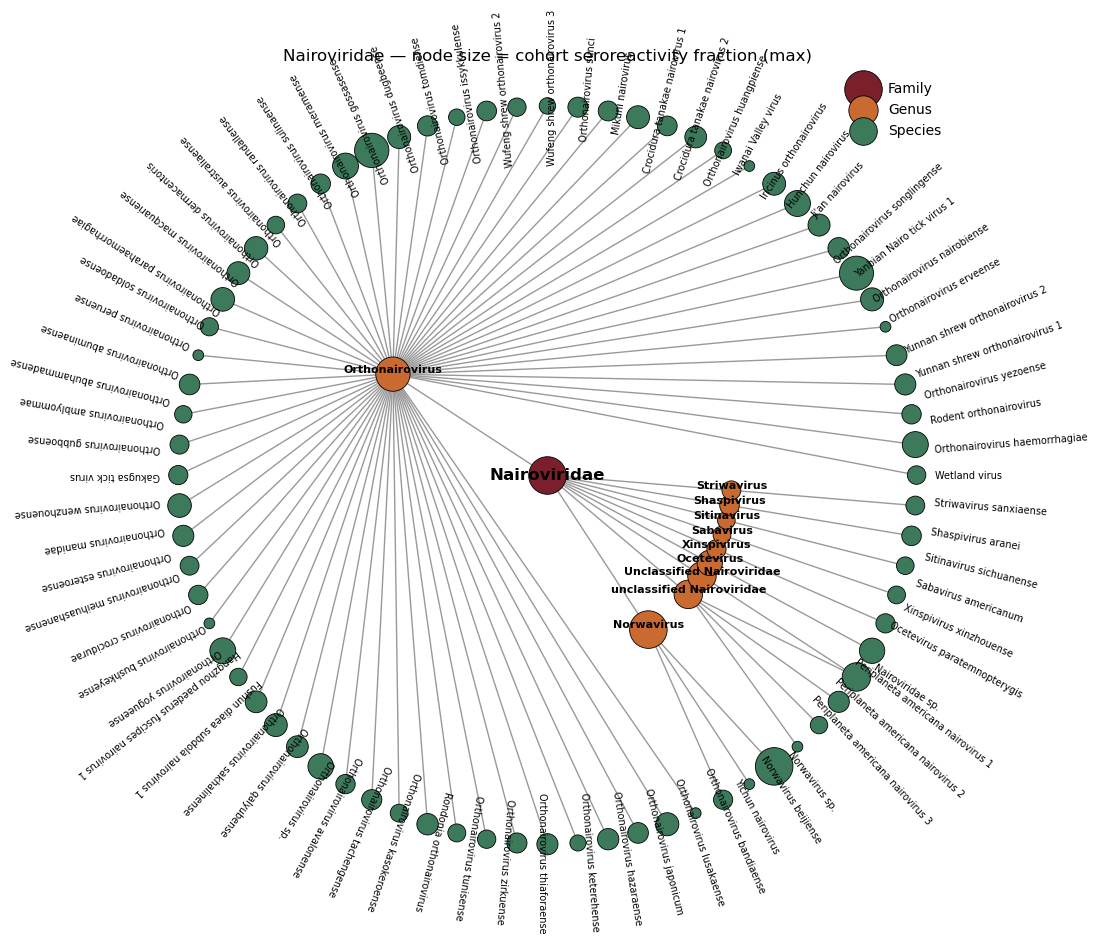

[Nairoviridae] 87 nodes -> taxonomy_trees_out/Nairoviridae.png, taxonomy_trees_out/Nairoviridae.nwk


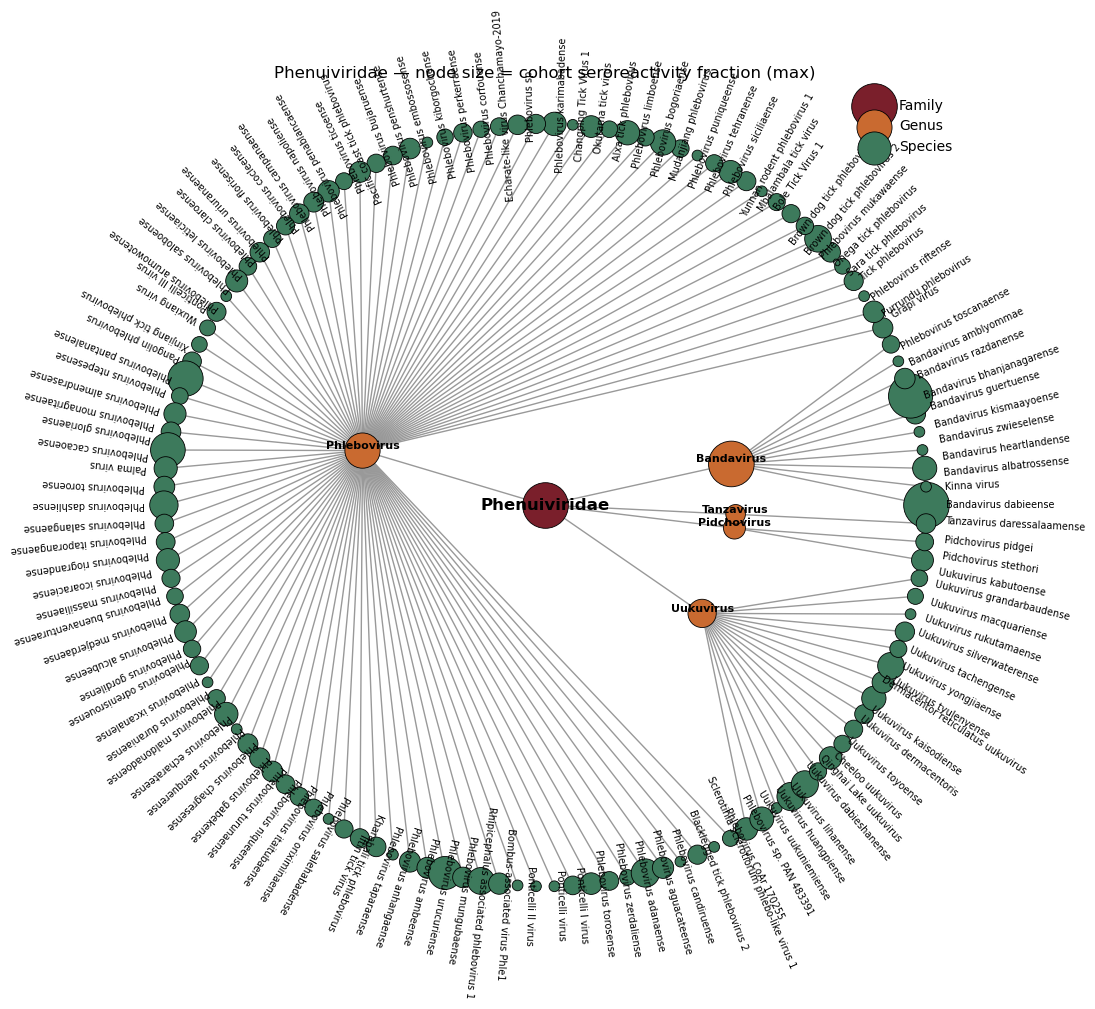

[Phenuiviridae] 136 nodes -> taxonomy_trees_out/Phenuiviridae.png, taxonomy_trees_out/Phenuiviridae.nwk


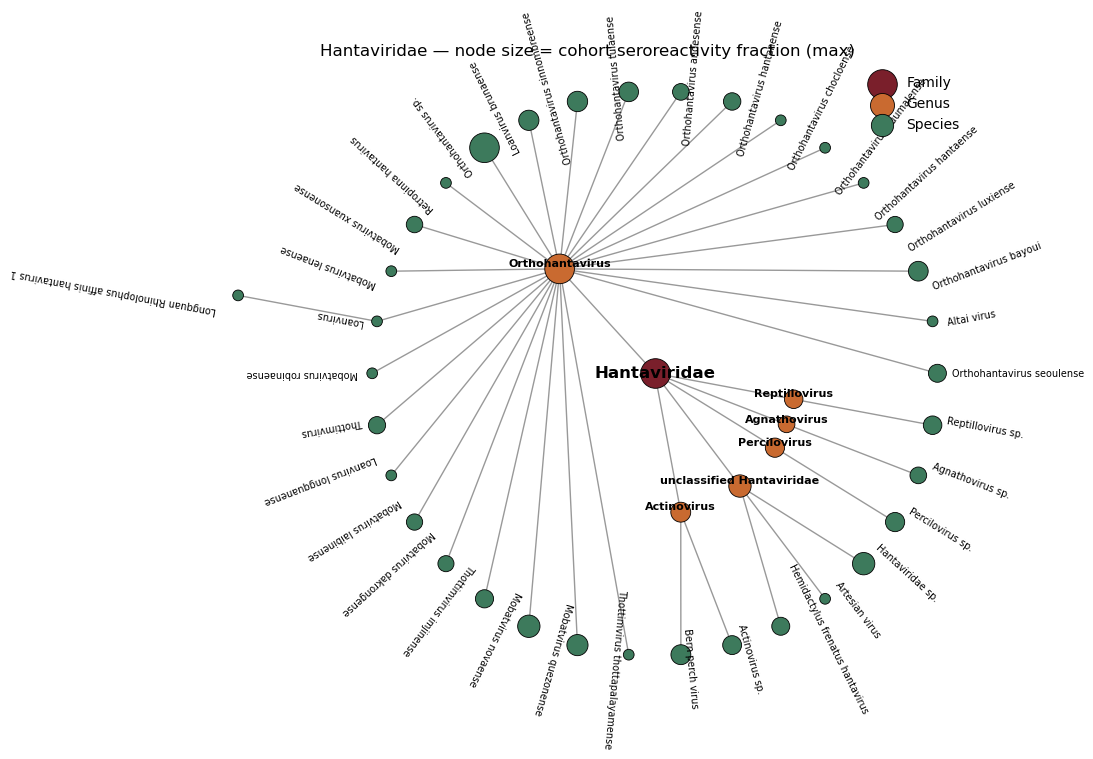

[Hantaviridae] 42 nodes -> taxonomy_trees_out/Hantaviridae.png, taxonomy_trees_out/Hantaviridae.nwk


In [11]:
trees = {}
for family in FAMILIES:
    G = build_family_tree(family, hits_df, library_df)
    if G is None:
        continue
    trees[family] = G
    png_path = OUTDIR / f"{family}.png"
    nwk_path = OUTDIR / f"{family}.nwk"
    plot_tree(G, family, png_path)
    nwk_path.write_text(to_newick(G, family))
    print(f"[{family}] {G.number_of_nodes()} nodes -> {png_path}, {nwk_path}")

In [ ]:
family = FAMILIES[0]
G = trees[family]
pd.DataFrame(
    [(n, d["level"], d["size"]) for n, d in G.nodes(data=True)],
    columns=["node", "level", "size"],
).sort_values(["level", "size"], ascending=[True, False])

In [8]:
print(lib_df[FAMILY_COL].unique())
print(hits_df[FAMILY_COL].unique())

NameError: name 'lib_df' is not defined